# **Problem Statement**

## Business Context

A sales forecast is a prediction of future sales revenue based on historical data, industry trends, and the status of the current sales pipeline. Businesses use the sales forecast to estimate weekly, monthly, quarterly, and annual sales totals. A company needs to make an accurate sales forecast as it adds value across an organization and helps the different verticals to chalk out their future course of action.

Forecasting helps an organization plan its sales operations by region and provides valuable insights to the supply chain team regarding the procurement of goods and materials. An accurate sales forecast process has many benefits which include improved decision-making about the future and reduction of sales pipeline and forecast risks. Moreover, it helps to reduce the time spent in planning territory coverage and establish benchmarks that can be used to assess trends in the future.

## Objective

SuperKart is a retail chain operating supermarkets and food marts across various tier cities, offering a wide range of products. To optimize its inventory management and make informed decisions around regional sales strategies, SuperKart wants to accurately forecast the sales revenue of its outlets for the upcoming quarter.

To operationalize these insights at scale, the company has partnered with a data science firm—not just to build a predictive model based on historical sales data, but to develop and deploy a robust forecasting solution that can be integrated into SuperKart’s decision-making systems and used across its network of stores.

## Data Description

The data contains the different attributes of the various products and stores.The detailed data dictionary is given below.

- **Product_Id** - unique identifier of each product, each identifier having two letters at the beginning followed by a number.
- **Product_Weight** - weight of each product
- **Product_Sugar_Content** - sugar content of each product like low sugar, regular and no sugar
- **Product_Allocated_Area** - ratio of the allocated display area of each product to the total display area of all the products in a store
- **Product_Type** - broad category for each product like meat, snack foods, hard drinks, dairy, canned, soft drinks, health and hygiene, baking goods, bread, breakfast, frozen foods, fruits and vegetables, household, seafood, starchy foods, others
- **Product_MRP** - maximum retail price of each product
- **Store_Id** - unique identifier of each store
- **Store_Establishment_Year** - year in which the store was established
- **Store_Size** - size of the store depending on sq. feet like high, medium and low
- **Store_Location_City_Type** - type of city in which the store is located like Tier 1, Tier 2 and Tier 3. Tier 1 consists of cities where the standard of living is comparatively higher than its Tier 2 and Tier 3 counterparts.
- **Store_Type** - type of store depending on the products that are being sold there like Departmental Store, Supermarket Type 1, Supermarket Type 2 and Food Mart
- **Product_Store_Sales_Total** - total revenue generated by the sale of that particular product in that particular store


# **Installing and Importing the necessary libraries**

In [68]:
#Installing the libraries with the specified versions
!pip install numpy==2.0.2 pandas==2.2.2 scikit-learn==1.6.1 matplotlib==3.10.0 seaborn==0.13.2 joblib==1.4.2 xgboost==2.1.4 requests==2.32.4 huggingface_hub==0.34.0 -q

  error: subprocess-exited-with-error
  
  × Preparing metadata (pyproject.toml) did not run successfully.
  │ exit code: 1
  ╰─> [685 lines of output]
      + /Library/Frameworks/Python.framework/Versions/3.13/bin/python3.13 /private/var/folders/q0/pqtw7nq564x11ncp3vsppq800000gn/T/pip-install-4y6xmfdg/numpy_1de7ea833fd149a5a3090c37b1e577e0/vendored-meson/meson/meson.py setup /private/var/folders/q0/pqtw7nq564x11ncp3vsppq800000gn/T/pip-install-4y6xmfdg/numpy_1de7ea833fd149a5a3090c37b1e577e0 /private/var/folders/q0/pqtw7nq564x11ncp3vsppq800000gn/T/pip-install-4y6xmfdg/numpy_1de7ea833fd149a5a3090c37b1e577e0/.mesonpy-mwvtizoe -Dbuildtype=release -Db_ndebug=if-release -Db_vscrt=md --native-file=/private/var/folders/q0/pqtw7nq564x11ncp3vsppq800000gn/T/pip-install-4y6xmfdg/numpy_1de7ea833fd149a5a3090c37b1e577e0/.mesonpy-mwvtizoe/meson-python-native-file.ini
      The Meson build system
      Version: 1.4.99
      Source dir: /private/var/folders/q0/pqtw7nq564x11ncp3vsppq800000gn/T/pip-instal

**Note:**

- After running the above cell, kindly restart the notebook kernel (for Jupyter Notebook) or runtime (for Google Colab) and run all cells sequentially from the next cell.

- On executing the above line of code, you might see a warning regarding package dependencies. This error message can be ignored as the above code ensures that all necessary libraries and their dependencies are maintained to successfully execute the code in this notebook.

In [21]:
import warnings
warnings.filterwarnings("ignore")

# Libraries to help with reading and manipulating data
import numpy as np
import pandas as pd
from pathlib import Path

# For splitting the dataset
from sklearn.model_selection import train_test_split

# Libaries to help with data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Removes the limit for the number of displayed columns
pd.set_option("display.max_columns", None)
# Sets the limit for the number of displayed rows
pd.set_option("display.max_rows", 100)


# Libraries different ensemble classifiers
from sklearn.ensemble import (
    BaggingRegressor,
    RandomForestRegressor,
    AdaBoostRegressor,
    GradientBoostingRegressor,
)
from xgboost import XGBRegressor
from sklearn.tree import DecisionTreeRegressor

# Libraries to get different metric scores
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    mean_squared_error,
    mean_absolute_error,
    r2_score,
    mean_absolute_percentage_error
)

# To create the pipeline
from sklearn.compose import make_column_transformer
from sklearn.pipeline import make_pipeline, Pipeline

# To tune different models and standardize
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# To serialize the model
import joblib

# os related functionalities
import os

# API request
import requests

# for hugging face space authentication to upload files
from huggingface_hub import login, HfApi


# **Loading the dataset**

In [22]:
df = pd.read_csv("SuperKart.csv")
print("Dataset shape:", df.shape)
df.head()

Dataset shape: (8763, 12)


,Product_Id,Product_Weight,Product_Sugar_Content,Product_Allocated_Area,Product_Type,Product_MRP,Store_Id,Store_Establishment_Year,Store_Size,Store_Location_City_Type,Store_Type,Product_Store_Sales_Total
0,FD6114,12.66,Low Sugar,0.027,Frozen Foods,117.08,OUT004,2009,Medium,Tier 2,Supermarket Type2,2842.40
1,FD7839,16.54,Low Sugar,0.144,Dairy,171.43,OUT003,1999,Medium,Tier 1,Departmental Store,4830.02
2,FD5075,14.28,Regular,0.031,Canned,162.08,OUT001,1987,High,Tier 2,Supermarket Type1,4130.16
3,FD8233,12.10,Low Sugar,0.112,Baking Goods,186.31,OUT001,1987,High,Tier 2,Supermarket Type1,4132.18
4,NC1180,9.57,No Sugar,0.010,Health and Hygiene,123.67,OUT002,1998,Small,Tier 3,Food Mart,2279.36


# **Data Overview**

In [23]:
df.head()
print("\nColumns:", list(df.columns))
print("\nShape:", df.shape)
print("\nMissing values:\n", df.isnull().sum())
print("\nData types:\n", df.dtypes)


Columns: ['Product_Id', 'Product_Weight', 'Product_Sugar_Content', 'Product_Allocated_Area', 'Product_Type', 'Product_MRP', 'Store_Id', 'Store_Establishment_Year', 'Store_Size', 'Store_Location_City_Type', 'Store_Type', 'Product_Store_Sales_Total']

Shape: (8763, 12)

Missing values:
 Product_Id                   0
Product_Weight               0
Product_Sugar_Content        0
Product_Allocated_Area       0
Product_Type                 0
Product_MRP                  0
Store_Id                     0
Store_Establishment_Year     0
Store_Size                   0
Store_Location_City_Type     0
Store_Type                   0
Product_Store_Sales_Total    0
dtype: int64

Data types:
 Product_Id                    object
Product_Weight               float64
Product_Sugar_Content         object
Product_Allocated_Area       float64
Product_Type                  object
Product_MRP                  float64
Store_Id                      object
Store_Establishment_Year       int64
Store_Size        

# **Exploratory Data Analysis (EDA)**

## Univariate Analysis

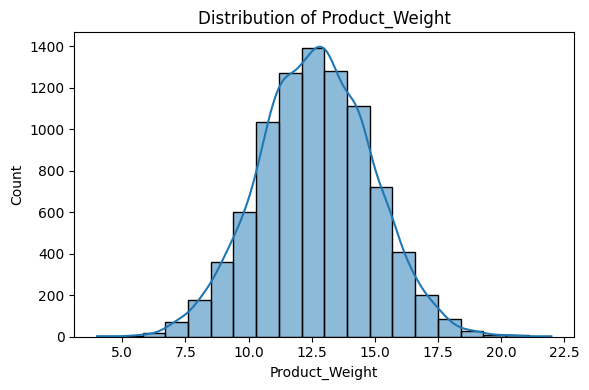

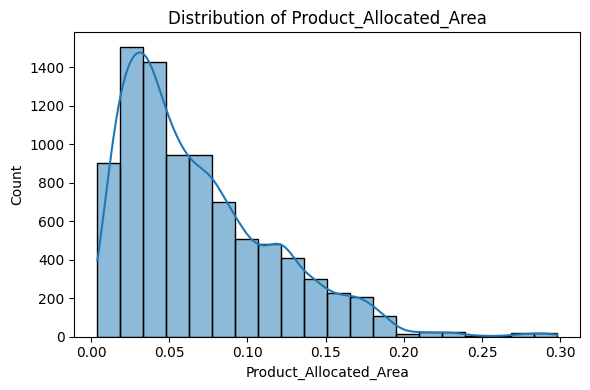

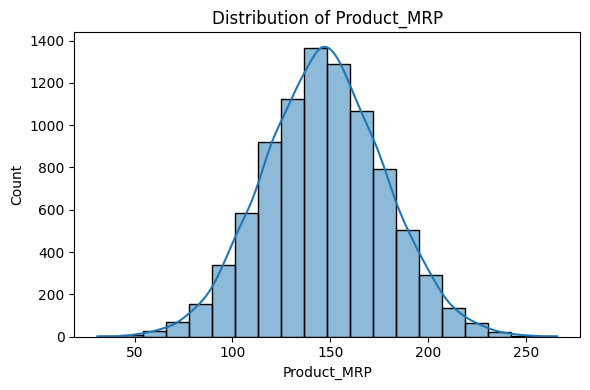

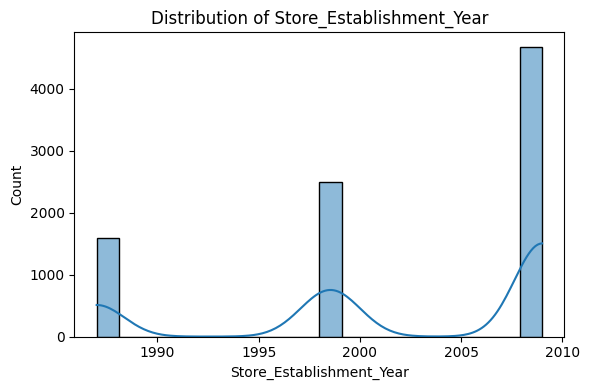

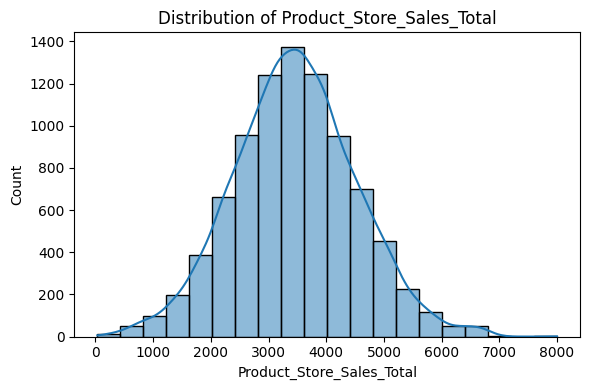

In [24]:
numeric_cols = df.select_dtypes(include=["number"]).columns.tolist()
for col in numeric_cols:
    plt.figure(figsize=(6, 4))
    sns.histplot(df[col], bins=20, kde=True)
    plt.title(f"Distribution of {col}")
    plt.tight_layout()
    plt.show()

## Bivariate Analysis

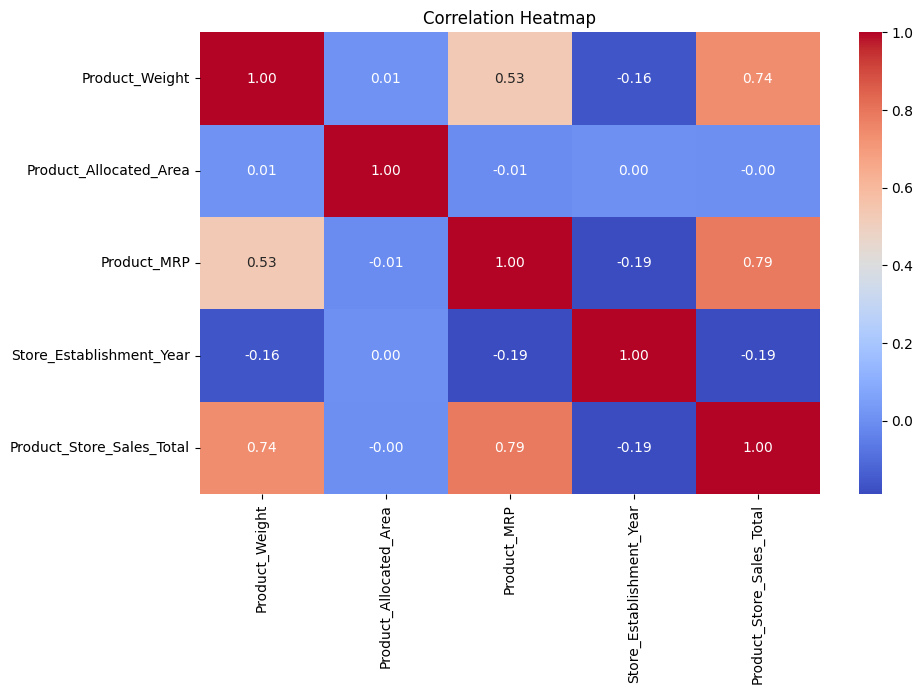

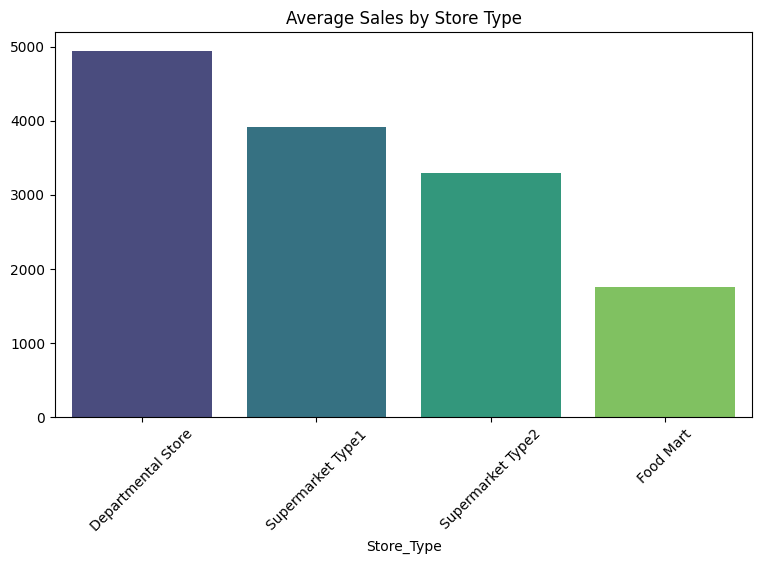

In [25]:
plt.figure(figsize=(10, 6))
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

avg_sales_by_store = df.groupby("Store_Type")["Product_Store_Sales_Total"].mean().sort_values(ascending=False)
plt.figure(figsize=(9, 5))
sns.barplot(x=avg_sales_by_store.index, y=avg_sales_by_store.values, palette="viridis")
plt.title("Average Sales by Store Type")
plt.xticks(rotation=45)
plt.show()

# **Data Preprocessing**

In [26]:
df["Product_Id_char"] = df["Product_Id"].str[:2]
df["Store_Age_Years"] = 2026 - df["Store_Establishment_Year"]

product_category_map = {
    "Meat": "Perishables",
    "Seafood": "Perishables",
    "Fruits and Vegetables": "Perishables",
    "Bread": "Perishables",
    "Breakfast": "Perishables",
    "Frozen Foods": "Perishables",
    "Dairy": "Perishables",
    "Baking Goods": "Perishables",
    "Starchy Foods": "Perishables",
    "Health and Hygiene": "Non Perishables",
    "Hard Drinks": "Non Perishables",
    "Household": "Non Perishables",
    "Canned": "Non Perishables",
    "Soft Drinks": "Non Perishables",
    "Snack Foods": "Non Perishables",
    "Others": "Non Perishables",
}

df["Product_Type_Category"] = df["Product_Type"].map(product_category_map)

feature_columns = [
    "Product_Weight",
    "Product_Sugar_Content",
    "Product_Allocated_Area",
    "Product_MRP",
    "Store_Size",
    "Store_Location_City_Type",
    "Store_Type",
    "Product_Id_char",
    "Store_Age_Years",
    "Product_Type_Category",
]

X = df[feature_columns]
y = df["Product_Store_Sales_Total"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

X_train.head()

,Product_Weight,Product_Sugar_Content,Product_Allocated_Area,Product_MRP,Store_Size,Store_Location_City_Type,Store_Type,Product_Id_char,Store_Age_Years,Product_Type_Category
5967,13.64,No Sugar,0.071,157.10,Medium,Tier 2,Supermarket Type2,NC,17,Non Perishables
8270,10.03,Low Sugar,0.016,126.66,High,Tier 2,Supermarket Type1,FD,39,Perishables
100,12.26,Low Sugar,0.140,138.27,Medium,Tier 2,Supermarket Type2,FD,17,Non Perishables
3410,10.28,Low Sugar,0.143,147.44,Medium,Tier 2,Supermarket Type2,FD,17,Non Perishables
1790,16.38,Low Sugar,0.082,205.16,Medium,Tier 1,Departmental Store,FD,27,Perishables


# **Model Building**

## Define functions for Model Evaluation

In [27]:
# function to compute adjusted R-squared
def adj_r2_score(predictors, targets, predictions):
    r2 = r2_score(targets, predictions)
    n = predictors.shape[0]
    k = predictors.shape[1]
    return 1 - ((1 - r2) * (n - 1) / (n - k - 1))


# function to compute different metrics to check performance of a regression model
def model_performance_regression(model, predictors, target):
    """
    Function to compute different metrics to check regression model performance

    model: regressor
    predictors: independent variables
    target: dependent variable
    """

    # predicting using the independent variables
    pred = model.predict(predictors)

    r2 = r2_score(target, pred)  # to compute R-squared
    adjr2 = adj_r2_score(predictors, target, pred)  # to compute adjusted R-squared
    rmse = np.sqrt(mean_squared_error(target, pred))  # to compute RMSE
    mae = mean_absolute_error(target, pred)  # to compute MAE
    mape = mean_absolute_percentage_error(target, pred)  # to compute MAPE

    # creating a dataframe of metrics
    df_perf = pd.DataFrame(
        {
            "RMSE": rmse,
            "MAE": mae,
            "R-squared": r2,
            "Adj. R-squared": adjr2,
            "MAPE": mape,
        },
        index=[0],
    )

    return df_perf

The ML models to be built can be any two out of the following:
1. Decision Tree
2. Bagging
3. Random Forest
4. AdaBoost
5. Gradient Boosting
6. XGBoost

In [28]:
categorical_features = [
    "Product_Sugar_Content",
    "Store_Size",
    "Store_Location_City_Type",
    "Store_Type",
    "Product_Id_char",
    "Product_Type_Category",
]
numeric_features = [col for col in X_train.columns if col not in categorical_features]

preprocessor = make_column_transformer(
    (OneHotEncoder(handle_unknown="ignore", sparse_output=False), categorical_features),
    ("passthrough", numeric_features)
)

rf_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestRegressor(random_state=42, n_estimators=300, min_samples_leaf=2))
])

xgb_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", XGBRegressor(
        objective="reg:squarederror",
        n_estimators=300,
        max_depth=6,
        learning_rate=0.05,
        random_state=42,
    ))
])

rf_model.fit(X_train, y_train)
xgb_model.fit(X_train, y_train)

rf_predictions = rf_model.predict(X_test)
xgb_predictions = xgb_model.predict(X_test)

print("Random Forest RMSE:", np.sqrt(mean_squared_error(y_test, rf_predictions)))
print("XGBoost RMSE:", np.sqrt(mean_squared_error(y_test, xgb_predictions)))

Random Forest RMSE: 278.509604064641
XGBoost RMSE: 291.4659777132312


# **Model Performance Improvement - Hyperparameter Tuning**

In [29]:
param_grid_rf = {
    "model__n_estimators": [200, 300],
    "model__max_depth": [None, 10, 20],
    "model__min_samples_leaf": [1, 2],
}

param_grid_xgb = {
    "model__n_estimators": [200, 300],
    "model__learning_rate": [0.03, 0.05],
    "model__max_depth": [4, 6],
}

tuned_rf = GridSearchCV(
    rf_model,
    param_grid_rf,
    cv=3,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1,
)

tuned_xgb = GridSearchCV(
    xgb_model,
    param_grid_xgb,
    cv=3,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1,
)

tuned_rf.fit(X_train, y_train)
tuned_xgb.fit(X_train, y_train)

print("Best RF params:", tuned_rf.best_params_)
print("Best XGB params:", tuned_xgb.best_params_)

Best RF params: {'model__max_depth': 20, 'model__min_samples_leaf': 2, 'model__n_estimators': 300}
Best XGB params: {'model__learning_rate': 0.03, 'model__max_depth': 6, 'model__n_estimators': 200}


# **Model Performance Comparison, Final Model Selection, and Serialization**

In [30]:
best_model = tuned_rf if tuned_rf.best_score_ > tuned_xgb.best_score_ else tuned_xgb
best_predictions = best_model.predict(X_test)

performance_df = pd.DataFrame(
    {
        "Model": ["Random Forest", "XGBoost", "Best Tuned Model"],
        "RMSE": [
            np.sqrt(mean_squared_error(y_test, rf_model.predict(X_test))),
            np.sqrt(mean_squared_error(y_test, xgb_model.predict(X_test))),
            np.sqrt(mean_squared_error(y_test, best_predictions)),
        ],
        "MAE": [
            mean_absolute_error(y_test, rf_model.predict(X_test)),
            mean_absolute_error(y_test, xgb_model.predict(X_test)),
            mean_absolute_error(y_test, best_predictions),
        ],
        "R2": [
            r2_score(y_test, rf_model.predict(X_test)),
            r2_score(y_test, xgb_model.predict(X_test)),
            r2_score(y_test, best_predictions),
        ],
    }
)

print(performance_df)
model_file = "backend_files/superkart_model.joblib"
os.makedirs(os.path.dirname(model_file), exist_ok=True)
joblib.dump(best_model, model_file)
print(f"Saved model to {model_file}")

              Model        RMSE         MAE        R2
0     Random Forest  278.509604  105.067511  0.932019
1           XGBoost  291.465978  120.830461  0.925547
2  Best Tuned Model  278.558074  105.138020  0.931995
Saved model to backend_files/superkart_model.joblib


# **Deployment - Backend**

## Points to note before executing the below cells
- Create a GitHub account if you don't already have one at [github.com](https://github.com)
- Generate a **Personal Access Token**
  - Make sure the token has **repo** scope (full control of private repositories)
- The serialized ML model file (`superkart_model.joblib`) should already be present in the `backend_files` folder before pushing to GitHub
- We will deploy **both the Flask backend and the Streamlit frontend as separate Docker containers** inside a GitHub Codespace, and connect them using a **Docker network**

## Flask Web Framework

Flask is a lightweight, flexible Python web framework used to build web applications and APIs quickly and easily.

Flask allows you to:
- Create web routes (URLs that users can access)
- Handle HTTP requests and responses
- Build REST APIs to expose machine learning models or other services

In [31]:
backend_path = Path("backend_files")
backend_path.mkdir(exist_ok=True)
backend_path.joinpath("app.py").write_text("""import os
import joblib
import pandas as pd
from flask import Flask, request, jsonify

app = Flask(__name__)
MODEL_PATH = os.path.join(os.getcwd(), "backend_files", "superkart_model.joblib")
model = joblib.load(MODEL_PATH)

FEATURE_COLUMNS = [
    "Product_Weight",
    "Product_Sugar_Content",
    "Product_Allocated_Area",
    "Product_MRP",
    "Store_Size",
    "Store_Location_City_Type",
    "Store_Type",
    "Product_Id_char",
    "Store_Age_Years",
    "Product_Type_Category",
]

@app.route("/health", methods=["GET"])
def health():
    return jsonify({"status": "ok"})

@app.route("/v1/predict", methods=["POST"])
def predict():
    data = request.get_json(force=True)
    if not data:
        return jsonify({"error": "Request body is required."}), 400

    record = pd.DataFrame([data])[FEATURE_COLUMNS]
    prediction = model.predict(record)[0]
    return jsonify({"prediction": float(prediction)})

@app.route("/v1/predictbatch", methods=["POST"])
def predict_batch():
    uploaded = request.files.get("file")
    if uploaded is None:
        return jsonify({"error": "Please upload a CSV file."}), 400

    dataframe = pd.read_csv(uploaded)
    missing = [column for column in FEATURE_COLUMNS if column not in dataframe.columns]
    if missing:
        return jsonify({"error": f"Missing required columns: {missing}"}), 400

    predictions = model.predict(dataframe[FEATURE_COLUMNS])
    return jsonify({str(index): float(value) for index, value in enumerate(predictions)})

if __name__ == "__main__":
    app.run(host="0.0.0.0", port=7860)
""")
print("Created backend_files/app.py")

Created backend_files/app.py


## Dependencies File

In [32]:
Path("backend_files/requirements.txt").write_text("Flask==3.0.3\npandas==2.2.2\nnumpy==2.0.2\nscikit-learn==1.6.1\nxgboost==2.1.4\njoblib==1.4.2\n")
print("Created backend_files/requirements.txt")

Created backend_files/requirements.txt


## Dockerfile

In [33]:
Path("backend_files/Dockerfile").write_text("FROM python:3.11-slim\n\nWORKDIR /app\n\nCOPY requirements.txt ./\nRUN pip install --no-cache-dir -r requirements.txt\n\nCOPY . .\n\nEXPOSE 7860\n\nCMD [\"python\", \"backend_files/app.py\"]\n")
print("Created backend_files/Dockerfile")

Created backend_files/Dockerfile


# **Deployment - Frontend**

## Streamlit for Interactive UI

In [34]:
frontend_path = Path("frontend_files")
frontend_path.mkdir(exist_ok=True)
frontend_path.joinpath("streamlit_app.py").write_text("""import os
import requests
import streamlit as st
import pandas as pd

API_URL = os.getenv("MODEL_API_URL", "http://localhost:7860")

st.title("SuperKart Sales Forecast")

with st.form("prediction_form"):
    product_weight = st.number_input("Product Weight", value=12.66)
    product_sugar = st.selectbox("Product Sugar Content", ["Low Sugar", "Regular", "No Sugar"])
    product_area = st.number_input("Product Allocated Area", value=0.027)
    product_mrp = st.number_input("Product MRP", value=117.08)
    store_size = st.selectbox("Store Size", ["Small", "Medium", "High"])
    city_type = st.selectbox("Store Location City Type", ["Tier 1", "Tier 2", "Tier 3"])
    store_type = st.selectbox("Store Type", ["Departmental Store", "Supermarket Type1", "Supermarket Type2", "Food Mart"])
    product_id_char = st.selectbox("Product Id Prefix", ["FD", "NC", "DR"])
    store_age_years = st.number_input("Store Age (Years)", value=16)
    product_type_category = st.selectbox("Product Type Category", ["Perishables", "Non Perishables"])
    submitted = st.form_submit_button("Predict Sales")

if submitted:
    payload = {
        "Product_Weight": product_weight,
        "Product_Sugar_Content": product_sugar,
        "Product_Allocated_Area": product_area,
        "Product_MRP": product_mrp,
        "Store_Size": store_size,
        "Store_Location_City_Type": city_type,
        "Store_Type": store_type,
        "Product_Id_char": product_id_char,
        "Store_Age_Years": store_age_years,
        "Product_Type_Category": product_type_category,
    }
    response = requests.post(f"{API_URL}/v1/predict", json=payload, timeout=30)
    if response.status_code == 200:
        st.success(f"Predicted Sales: ${response.json()['prediction']:.2f}")
    else:
        st.error(f"Prediction failed: {response.text}")

uploaded_file = st.file_uploader("Upload batch CSV", type=["csv"])
if uploaded_file is not None:
    files = {"file": (uploaded_file.name, uploaded_file.getvalue(), "text/csv")}
    response = requests.post(f"{API_URL}/v1/predictbatch", files=files, timeout=60)
    if response.status_code == 200:
        st.json(response.json())
    else:
        st.error(f"Batch prediction failed: {response.text}")
""")
print("Created frontend_files/streamlit_app.py")

Created frontend_files/streamlit_app.py


## Dependencies File

In [35]:
Path("frontend_files/requirements.txt").write_text("streamlit==1.38.0\npandas==2.2.2\nnumpy==2.0.2\nrequests==2.32.4\n")
print("Created frontend_files/requirements.txt")

Created frontend_files/requirements.txt


## Dockerfile

In [36]:
Path("frontend_files/Dockerfile").write_text("FROM python:3.11-slim\n\nWORKDIR /app\n\nCOPY requirements.txt ./\nRUN pip install --no-cache-dir -r requirements.txt\n\nCOPY . .\n\nEXPOSE 8501\n\nCMD [\"streamlit\", \"run\", \"streamlit_app.py\", \"--server.address\", \"0.0.0.0\", \"--server.port\", \"8501\"]\n")
print("Created frontend_files/Dockerfile")

Created frontend_files/Dockerfile


# **Pushing Deployment Files to GitHub**

In [37]:
import subprocess

commands = [
    "git init",
    "git add .",
    "git commit -m 'Initial deployment files'",
]
for command in commands:
    print(f"$ {command}")
    subprocess.run(command, shell=True, check=False)
print("Git commands prepared. Replace remote URL before pushing.")

$ git init
Reinitialized existing Git repository in /Users/rajaagireddy/UTAI/ModelDeployment/.git/
$ git add .
$ git commit -m 'Initial deployment files'
[main 4a1846a] Initial deployment files
 2 files changed, 30 insertions(+), 18 deletions(-)
Git commands prepared. Replace remote URL before pushing.


# **Inferencing using Flask API**

As the ***frontend and backend are decoupled***, we can ***access the backend directly for predictions***.
- The decoupling ensures seamless interaction with the deployed model while leveraging the API for scalable inference.

Let's see how to interact with the deployed Flask API running inside a GitHub Codespace to perform **online** and **batch inference** from this Colab notebook.

We will:
1. Send API requests for both online and batch inference.
2. Process and check the model predictions.

**Before running the cells below**, make sure:
- Your Codespace is running with both containers up
- Port 7860 has been set to **Public** in the Codespace Ports tab
- You have copied the forwarded URL for port 7860
- You have also referred the document titled **`Guided Hands-on - Containerized Model Deployment using GitHub Codespaces`** provided

In [38]:
import json  # To handle JSON formatting for API requests and responses
import requests  # To send HTTP requests to the deployed Flask API

import pandas as pd  # For data manipulation and analysis
import numpy as np  # For numerical computations

In [39]:
model_root_url = "https://improved-tribble-5vg976jxwjvfv4-7860.app.github.dev"  # Replace with your Codespace forwarded URL
#model_root_url = "http://127.0.0.1:7860"

Replace the URL above with the actual forwarded URL from your Codespace's Ports tab. It will look something like `https://organic-space-abcd1234-7860.app.github.dev`. Make sure there is no trailing slash at the end.

This URL is a tunnel that Codespaces creates to route external HTTP requests into your Codespace and to the Flask container running on port 7860.

In [40]:
model_url = model_root_url + "/v1/predict"  # Endpoint for online (single) inference

Since our model predictions are provided by the following endpoint we created using Flask, we need to invoke the same to make prediction.

> ```@superkart_api.post('/v1/predict')```

In [41]:
model_batch_url = model_root_url + "/v1/predictbatch"  # Endpoint for batch inference

> ```@superkart_api.post('/v1/predictbatch')```

## Online

**Online Inference:** Sending a single request to the API and receiving an immediate response. This is useful for real-time applications like recommendation systems and fraud detection.  
* This data is sent as a JSON payload in a POST request to the model endpoint.

* The model processes the input features and returns a prediction.

In [51]:
payload = {
  "Product_Weight": 12.66,
  "Product_Sugar_Content": "Low Sugar",
  "Product_Allocated_Area": 0.027,
  "Product_MRP": 117.08,
  "Store_Size": "Medium",
  "Store_Location_City_Type": "Tier 2",
  "Store_Type": "Supermarket Type2",
  "Product_Id_char": "FD",
  "Store_Age_Years": 16,
  "Product_Type_Category": "Non Perishables"
}

In [49]:
# Sending a POST request to the model endpoint with the test payload
import requests

response = requests.post(model_url, json=payload, timeout=30)
print("status:", response.status_code)
print(response.text)

try:
    print(response.json())
except ValueError:
    print("Non-JSON response received")

status: 200
{"prediction":2933.215045740742}

{'prediction': 2933.215045740742}


In [15]:
response

<Response [502]>

`<Response [200]>` indicates that the HTTP request was successful.  

- `Response` is the object returned by `requests.post()`.  
- `[200]` is the HTTP status code, meaning **OK** (the request was processed successfully).  

In [50]:
try:
    print(response.json())
except ValueError:
    print("Non-JSON response received")
    print("status:", response.status_code)
    print(response.text)

{'prediction': 2933.215045740742}


`response.json()` is used to parse the response body as JSON.  
- If the API returns data in JSON format, `.json()` converts it into a Python dictionary.  
- This allows easy access to specific values using keys.  

## Batch

**Batch Inference:** Sending multiple inputs in a single request, allowing efficient processing of large datasets. This is ideal for analyzing historical data at scale.

In [98]:
batch_dataset = pd.read_csv("Batch_Data_SuperKart.csv")

**Note**: The batch CSV file must contain all the feature columns expected by the model: `Product_Weight`, `Product_Sugar_Content`, `Product_Allocated_Area`, `Product_MRP`, `Store_Size`, `Store_Location_City_Type`, `Store_Type`, `Product_Id_char`, `Store_Age_Years`, `Product_Type_Category`.

In [99]:
# Prepare batch input for API request
batch_input = {
    'file': batch_dataset.to_csv(header=True, index=False).encode('utf-8')
}

This code prepares the product data as a **file-like object** to send in an API request (in the `files` parameter of `requests.post`).

- `batch_dataset`: This is a Pandas DataFrame containing the product data loaded from a CSV file.

- `.to_csv(header=True, index=False)`: Converts the DataFrame into a CSV **string**, keeping the column headers (`header=True`) but **excluding the index** (`index=False`).

- `.encode('utf-8')`: Encodes the CSV string into **bytes** (UTF-8 format), which is necessary for sending it over an HTTP request.

- `'file': ...`: Wraps the encoded CSV data in a dictionary with the key `'file'`, which is expected by the Flask backend.

In [100]:
# Send request to the model API for batch predictions
response = requests.post(
    model_batch_url,  # Model endpoint URL
    files=batch_input
)

This line sends a **POST request** to the deployed model API to perform **batch sales prediction**.

- `requests.post(...)`: This uses the `requests` library to make a **POST** request to a web server (in this case, our API endpoint for batch predictions).

- `model_batch_url`: This is the URL endpoint where the batch prediction API is hosted. It should look like this:\
  `"https://<your-codespace-name>-7860.app.github.dev/v1/predictbatch"`

- `files=batch_input`: This sends the batch data file (e.g., a CSV) as part of the request using the `files` parameter.

- `response`: This is the result of the API call and contains the response from the server, including predicted sales values.

In [101]:
response

<Response [200]>

In [102]:
# Extract predictions from API response
response.text

'{"0":4076.391513809523,"1":2960.406705800866,"2":4045.94243373016,"3":1912.7845552380957,"4":4084.9305976587307,"5":4964.49006345238,"6":2457.1078167989417,"7":2375.1661056216954,"8":4403.0474174867695,"9":2435.5778922619047}\n'

In [103]:
batch_dataset = pd.read_csv("Batch_Data_SuperKart.csv")
batch_input = {
    'file': batch_dataset.to_csv(header=True, index=False).encode('utf-8')
}

response = requests.post(model_batch_url, files=batch_input, timeout=60)
print("status:", response.status_code)
print(response.text)

status: 200
{"0":4076.391513809523,"1":2960.406705800866,"2":4045.94243373016,"3":1912.7845552380957,"4":4084.9305976587307,"5":4964.49006345238,"6":2457.1078167989417,"7":2375.1661056216954,"8":4403.0474174867695,"9":2435.5778922619047}



As we can see, we receive a JSON where each key represents a row index, and the value represents the model's predicted sales for that product.

# **Actionable Insights and Business Recommendations**

-

-